# Spotify Streaming Analysis

This project analyzes personal Spotify streaming history using Python.

### What the notebook shows
- loading and cleaning raw streaming data
- filtering to music tracks only

- computing key listening metrics
- analyzing overall listening behavior

- identifying top artists and tracks
- visualizing results with matplotlib

- examplatory design extension and spotify API-connection (Personal Fav :-))

### Tools used
- Python
- pandas
- matplotlib
- numpy
- Jupyter Notebook

### Next steps
Future extensions include Spotify API enrichment, scientific and more detailed analysis considering correlations, skip rates, prediction algorithms.

In [103]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from spotify_analysis.io import load_streaming_history
from spotify_analysis.clean import clean_streaming_history, get_tracks_clean_df
from spotify_analysis.metrics import (
    total_listening,
    total_streams,
    unique_counts,
    top_artists,
    top_tracks,
    listening_by_month,
    artist_summary
)
from spotify_analysis.enrich import (
    get_client_credentials_token,
    fetch_tracks_metadata)

## Data loading and cleaning

The raw Spotify export is loaded from disk and cleaned into an analysis-friendly format.
The analysis below focuses on music tracks only.

In [3]:
raw_df = load_streaming_history("../data/raw")
clean_df = clean_streaming_history(raw_df)
tracks_clean_df = get_tracks_clean_df(clean_df)

print("Raw shape:", raw_df.shape)
print("Clean shape:", clean_df.shape)
print("Track-only shape:", tracks_clean_df.shape)

Raw shape: (88656, 24)
Clean shape: (88656, 22)
Track-only shape: (88128, 22)


In [4]:
tracks_clean_df.sort_values(by="year", ascending=False).head()

,ts,date,year,month,month_num,hour,weekday,platform,conn_country,ms_played,...,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,track_id,skipped,shuffle,reason_start,reason_end,source_file,playback_type
88655,2026-03-23 17:45:37+00:00,2026-03-23,2026,2026-03,3,17,Monday,ios,DE,380,...,CA7RIEL & Paco Amoroso,Lo Quiero Ya !,spotify:track:3n1zNHtIFW0iOwiGqnkGnR,3n1zNHtIFW0iOwiGqnkGnR,True,False,unknown,endplay,Streaming_History_Video_2023-2026.json,track
70114,2026-02-04 22:20:26+00:00,2026-02-04,2026,2026-02,2,22,Wednesday,ios,DE,193629,...,L'Impératrice,Odyssée - EP,spotify:track:6rbbDK18oqK3MxHGQhpmn2,6rbbDK18oqK3MxHGQhpmn2,False,False,trackdone,trackdone,Streaming_History_Audio_2025-2026_5.json,track
70090,2026-02-04 20:51:46+00:00,2026-02-04,2026,2026-02,2,20,Wednesday,ios,DE,189091,...,Esbe,Bloomsday,spotify:track:6ncNLU982iaD9WFb2gTwKd,6ncNLU982iaD9WFb2gTwKd,False,False,trackdone,trackdone,Streaming_History_Audio_2025-2026_5.json,track
70091,2026-02-04 20:54:59+00:00,2026-02-04,2026,2026-02,2,20,Wednesday,ios,DE,198332,...,NEIL FRANCES,Teardrops,spotify:track:3GdogCZTpPHBODiiEJbqQm,3GdogCZTpPHBODiiEJbqQm,False,False,trackdone,trackdone,Streaming_History_Audio_2025-2026_5.json,track
70092,2026-02-04 20:58:22+00:00,2026-02-04,2026,2026-02,2,20,Wednesday,ios,DE,209281,...,Pale Jay,The Celestial Suite,spotify:track:0cr4j4bhchcuO86N9wAvH8,0cr4j4bhchcuO86N9wAvH8,False,False,trackdone,trackdone,Streaming_History_Audio_2025-2026_5.json,track


# Key metrics
A quick overview of total listening activity.

In [5]:
total_listening(tracks_clean_df)

,total_ms_played,total_minutes_played,total_hours_played
0,14165782099,236096.368317,3934.939472


In [6]:
total_streams(tracks_clean_df)

,total_streams
0,88128


In [7]:
unique_counts(tracks_clean_df)

,unique_tracks,unique_artists,unique_albums
0,29193,10415,18314


## Listening trend

The following exploratory analysis shows how music consumption (in min) evolves over years considering all-time streaming.

Blue line represents the evolution of streams per month, while orange illustrates the trendline on a rolling base.

In [8]:
#Preparation
monthly_df = listening_by_month(tracks_clean_df).copy()
monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df = monthly_df.sort_values("month")

monthly_df["trend_12m"] = (
    monthly_df["total_minutes_played"]
    .rolling(window=12, center=True)
    .mean()
)

#Check
monthly_df.head()

,month,total_streams,total_ms_played,total_minutes_played,trend_12m
0,2020-04-01,133,14423974,240.399567,NaN
1,2020-05-01,525,65237490,1087.291500,NaN
2,2020-06-01,161,12787011,213.116850,NaN
3,2020-07-01,111,11921313,198.688550,NaN
4,2020-08-01,71,8366472,139.441200,NaN


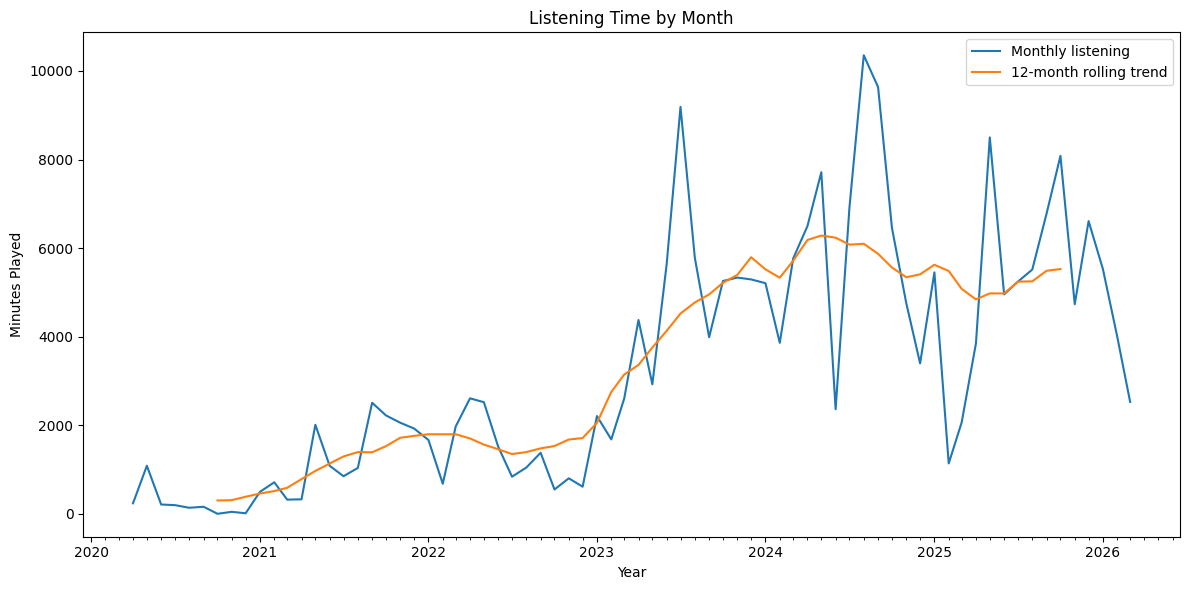

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_df["month"], monthly_df["total_minutes_played"], label="Monthly listening")
plt.plot(monthly_df["month"], monthly_df["trend_12m"], label="12-month rolling trend")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.xlabel("Year")
plt.ylabel("Minutes Played")
plt.title("Listening Time by Month")
plt.legend()
plt.tight_layout()
plt.show()

## Monthly trend by year

To compare data more thoroughly, e.g. seasonality across years, the data is split by year, keeping months on the x-axis.

In [35]:
#Preparation
monthly_by_year = (
    tracks_clean_df
    .assign(month_num=lambda d: pd.to_datetime(d["month"]).dt.month)
    .groupby(["year", "month_num"], dropna=False)
    .agg(
        total_streams=("track_id", "size"),
        total_ms_played=("ms_played", "sum"),
    )
    .reset_index()
)

monthly_by_year["total_minutes_played"] = monthly_by_year["total_ms_played"] / 60000
monthly_by_year.head()

,year,month_num,total_streams,total_ms_played,total_minutes_played
0,2020,4,133,14423974,240.399567
1,2020,5,525,65237490,1087.291500
2,2020,6,161,12787011,213.116850
3,2020,7,111,11921313,198.688550
4,2020,8,71,8366472,139.441200


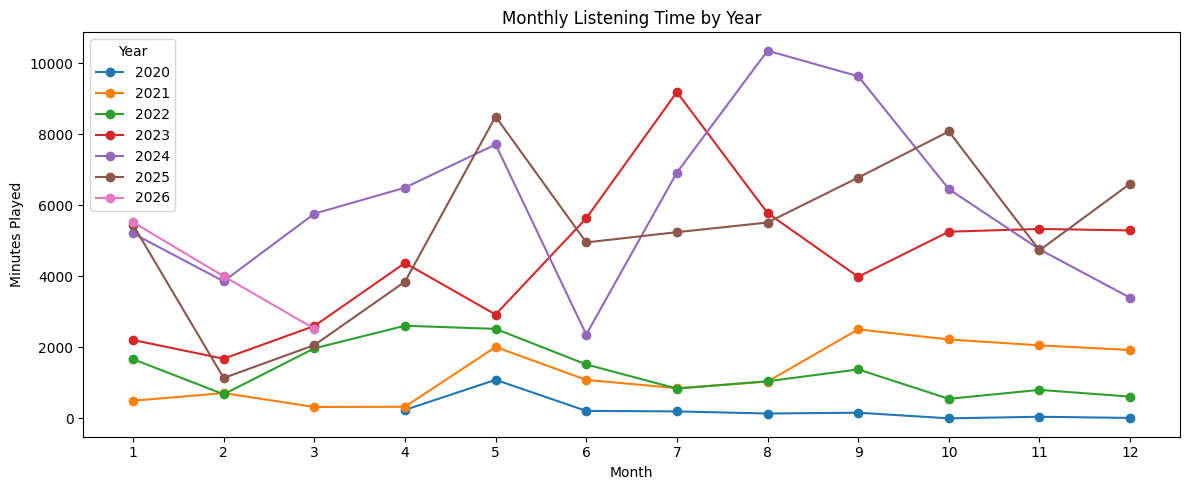

In [47]:
plt.figure(figsize=(12, 5))

for year, group in monthly_by_year.groupby("year"):
    plt.plot(group["month_num"], group["total_minutes_played"], marker="o", label=str(year))

plt.title("Monthly Listening Time by Year")
plt.xlabel("Month")
plt.ylabel("Minutes Played")
plt.xticks(range(1, 13))
plt.legend(title="Year")
plt.tight_layout()
plt.show()

## Top artists

Shows Top-Artists, ranked by total listening time.

In [58]:
top_artists_df = top_artists(tracks_clean_df).head(10).copy()
top_artists_df.index = range(1, len(top_artists_df) + 1)
top_artists_df

,artist_name,total_streams,total_ms_played,unique_tracks,total_minutes_played
1,East Forest,1399,254216248,132,4236.937467
2,CRO,1532,221692405,175,3694.873417
3,Jungle,1047,172755265,61,2879.254417
4,Edward Snowden,873,159898642,242,2664.977367
5,Ben Böhmer,706,145970049,64,2432.834150
6,Ludovico Einaudi,568,145711425,179,2428.523750
7,Khruangbin,680,143502421,83,2391.707017
8,Tash Sultana,509,136995162,81,2283.252700
9,Milky Chance,564,101600554,104,1693.342567
10,Eminem,542,93252050,180,1554.200833


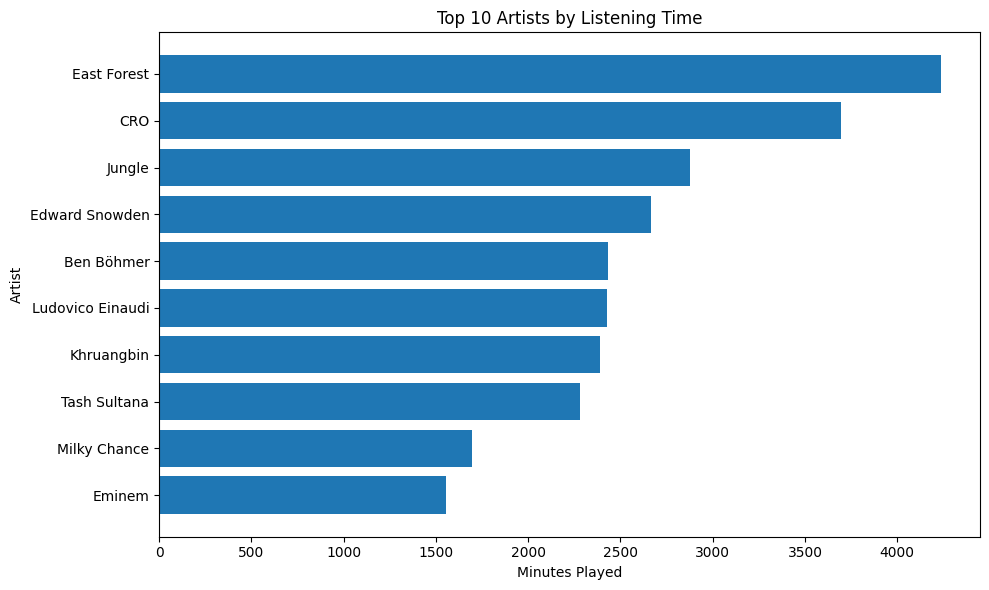

In [68]:
plot_df = top_artists_df.sort_values("total_minutes_played")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["artist_name"], plot_df["total_minutes_played"])

plt.title("Top 10 Artists by Listening Time")
plt.xlabel("Minutes Played")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

## Concentration of listening across artists

Listening behavior is often concentrated in a relatively small set of artists.

To quantify this concentration, this section computes:

- the share of total listening time explained by the top 10 artists
- the Gini coefficient across all artists
- the Lorenz curve as a visual summary of inequality

A higher concentration means that a small group of artists accounts for a disproportionately large share of listening time.

In [69]:
artist_summary_df = artist_summary(tracks_clean_df).copy()
artist_summary_df.head(n=15)

,artist_name,total_streams,total_ms_played,unique_tracks,total_minutes_played
0,East Forest,1399,254216248,132,4236.937467
1,CRO,1532,221692405,175,3694.873417
2,Jungle,1047,172755265,61,2879.254417
3,Edward Snowden,873,159898642,242,2664.977367
4,Ben Böhmer,706,145970049,64,2432.834150
5,Ludovico Einaudi,568,145711425,179,2428.523750
6,Khruangbin,680,143502421,83,2391.707017
7,Tash Sultana,509,136995162,81,2283.252700
8,Milky Chance,564,101600554,104,1693.342567
9,Eminem,542,93252050,180,1554.200833


In [77]:
total_time = tracks_clean_df["ms_played"].sum()
top10_time = artist_summary_df.head(10)["total_ms_played"].sum()

top10_share = top10_time / total_time

print(f"--> Top 10 artists share of total listening time: {top10_share:.2%}")

--> Top 10 artists share of total listening time: 11.12%


The top-10 share measures how much of all listening time comes from the ten most listened-to artists.

A higher value indicates that listening time is concentrated in a relatively small artist set.

In [78]:
artist_totals = artist_summary_df["total_ms_played"].to_numpy()
artist_totals = np.sort(artist_totals)

n = len(artist_totals)

if n == 0 or artist_totals.sum() == 0:
    gini = np.nan
else:
    cumvals = np.cumsum(artist_totals)
    gini = (n + 1 - 2 * cumvals.sum() / cumvals[-1]) / n

print(f"--> Gini coefficient across artists: {gini:.3f}")

--> Gini coefficient across artists: 0.809


The Gini coefficient summarizes inequality in listening time across artists.

- A value near 0 indicates a more even distribution.
- A value near 1 indicates a highly concentrated distribution.

In this context, a higher Gini value means that listening time is dominated by a smaller core set of artists.

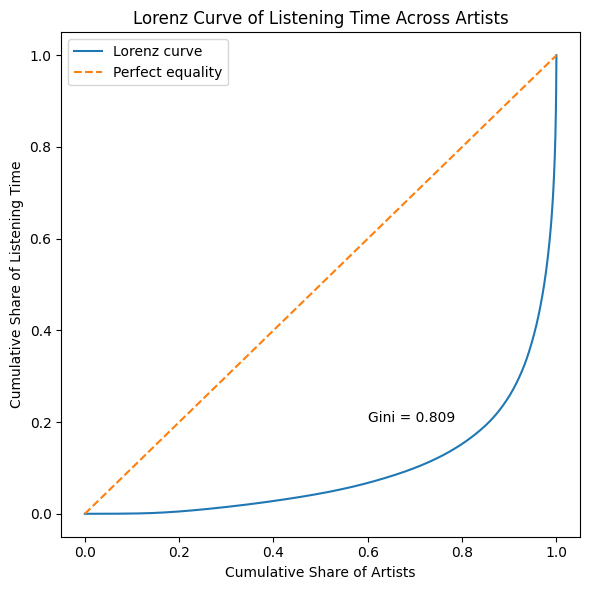

In [79]:
cum_artist_share = np.arange(1, len(artist_totals) + 1) / len(artist_totals)
cum_listening_share = np.cumsum(artist_totals) / artist_totals.sum()

cum_artist_share = np.insert(cum_artist_share, 0, 0)
cum_listening_share = np.insert(cum_listening_share, 0, 0)

plt.figure(figsize=(6, 6))

plt.plot(cum_artist_share, cum_listening_share, label="Lorenz curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect equality")

plt.text(0.6, 0.2, f"Gini = {gini:.3f}")

plt.title("Lorenz Curve of Listening Time Across Artists")
plt.xlabel("Cumulative Share of Artists")
plt.ylabel("Cumulative Share of Listening Time")
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
print(
    f"The top 10 artists account for {top10_share:.2%} of total listening time. "
    f"The Gini coefficient of {gini:.3f} indicates a concentrated listening pattern "
    f"across artists."
)

The top 10 artists account for 11.12% of total listening time. The Gini coefficient of 0.809 indicates a concentrated listening pattern across artists.



--> in this case, approximately only 1/4th of Streams come from 90% of Artists. 

A small share of 10% of all Artists listened to accounts for 75% of Streaming-time.

## Top tracks

Tracks are ranked by total listening time.

In [81]:
top_tracks_df = top_tracks(tracks_clean_df).head(10).copy()
top_tracks_df.index = range(1, len(top_tracks_df) + 1)
top_tracks_df

,track_name,artist_name,track_id,spotify_track_uri,total_ms_played,total_minutes_played
1,Meditation for Chaotic Times [Guided Meditation],East Forest,5qLnXacfQfxhlGtgNHPvIX,spotify:track:5qLnXacfQfxhlGtgNHPvIX,69245065,1154.084417
2,10 Laws,East Forest,6rv66YGnlPsCQHBU0ym8Tm,spotify:track:6rv66YGnlPsCQHBU0ym8Tm,30001696,500.028267
3,The Age Of Love (Charlotte de Witte & Enrico S...,Age Of Love,6R84ZlQF7gGkPB6o3GLZXB,spotify:track:6R84ZlQF7gGkPB6o3GLZXB,28322444,472.040733
4,The Art of Meditation,Sigur Rós,5FFnpCylEuwnuVq2l0L8zg,spotify:track:5FFnpCylEuwnuVq2l0L8zg,22489591,374.826517
5,Jungle,Tash Sultana,1KTObLMW9mwk2iPjP3daHb,spotify:track:1KTObLMW9mwk2iPjP3daHb,21992296,366.538267
6,letzter song,CRO,7EHEVPIFS6mOq4BOhlVL3i,spotify:track:7EHEVPIFS6mOq4BOhlVL3i,20912922,348.548700
7,Beyond Beliefs,Ben Böhmer,58ney0bG2Vwecj8QzNGRkV,spotify:track:58ney0bG2Vwecj8QzNGRkV,19661699,327.694983
8,TERRITORY,The Blaze,2W3EgJst61RLZtPPm3EQim,spotify:track:2W3EgJst61RLZtPPm3EQim,18027823,300.463717
9,Vale,Maribou State,58FsmlVRQxpjFmXF8vSKMT,spotify:track:58FsmlVRQxpjFmXF8vSKMT,17154447,285.907450
10,Yin Yoga II,Ryan Richko,0I0hWVtDPNhdFe0uF2qc7N,spotify:track:0I0hWVtDPNhdFe0uF2qc7N,15798075,263.301250


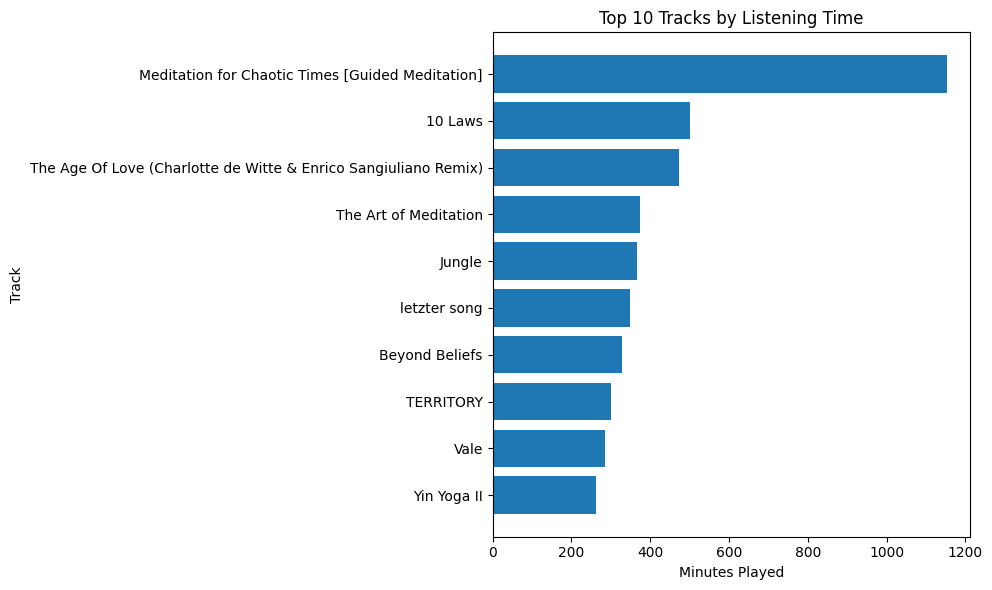

In [82]:
plot_df = top_tracks_df.sort_values("total_minutes_played")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["track_name"], plot_df["total_minutes_played"])

plt.title("Top 10 Tracks by Listening Time")
plt.xlabel("Minutes Played")
plt.ylabel("Track")
plt.tight_layout()
plt.show()

# Outlook

This Notebook illustrates some superficial analysis on user-level dataset requested from spotify.

Several extensions are necessary (for valid interpretations and implications),

as well as possible (e.g. regarding enrichment, API use, design). For example,

1) Connect to Spotify database and enrich song information using their API
2) Additional Information helps display e.g. Album Cover and relink the track to spotify-player

## Album Highlights from 2026 (Spotify-Wrapped)

Below are my three most-listened tracks by different artists in 2026, enriched with Spotify album art and preview information.

In [124]:
#Get most-consumed tracks in 2026 of different albums
top_tracks_2026 = (
    top_tracks(tracks_clean_df.loc[tracks_clean_df["year"] == 2026], n=50)
    .dropna(subset=["track_id", "artist_name"])
    .drop_duplicates(subset=["artist_name"])
    .head(3)
    .copy()
)

top_tracks_2026.head()


,track_name,artist_name,track_id,spotify_track_uri,total_ms_played,total_minutes_played
0,BAILE INoLVIDABLE,Bad Bunny,2lTm559tuIvatlT1u0JYG2,spotify:track:2lTm559tuIvatlT1u0JYG2,2836706,47.278433
1,Patient,Post Malone,5DLTuH4A5VZB2HKpqHQR6t,spotify:track:5DLTuH4A5VZB2HKpqHQR6t,2218849,36.980817
3,The Age Of Love (Charlotte de Witte & Enrico S...,Age Of Love,6R84ZlQF7gGkPB6o3GLZXB,spotify:track:6R84ZlQF7gGkPB6o3GLZXB,1860406,31.006767


In [125]:
#API-Extension
access_token = get_client_credentials_token()

tracks_meta_df = fetch_tracks_metadata(
    top_tracks_2026["track_id"].tolist(),
    access_token,
)

In [126]:
#Merge newly acquired infos
cards_df = top_tracks_2026.merge(
    tracks_meta_df,
    on="track_id",
    how="left",
)

#Add rank
cards_df = cards_df.reset_index(drop=True)
cards_df["rank"] = cards_df.index + 1

In [128]:
#Display in Card-style
from IPython.display import HTML, display

cards = []

for _, row in cards_df.iterrows():
    preview_html = ""
    if row.get("preview_url", "") != "":
        preview_html = f"""
        <audio controls style="width: 180px; margin-top: 10px;">
            <source src="{row['preview_url']}" type="audio/mpeg">
        </audio>
        """
    else:
        preview_html = """
        <div style="font-size: 12px; color: #888; margin-top: 10px;">
            No preview available
        </div>
        """

    minutes_html = ""
    if "total_minutes_played" in cards_df.columns and pd.notna(row.get("total_minutes_played")):
        minutes_html = f"""
        <div style="font-size: 12px; color: #444; margin-top: 8px;">
            {row['total_minutes_played']:.1f} minutes played
        </div>
        """

    streams_html = ""
    if "total_streams" in cards_df.columns and pd.notna(row.get("total_streams")):
        streams_html = f"""
        <div style="font-size: 12px; color: #444; margin-top: 4px;">
            {int(row['total_streams'])} streams
        </div>
        """

    card = f"""
    <div style="
        width: 220px;
        padding: 12px;
        border: 1px solid #ddd;
        border-radius: 12px;
        text-align: center;
        position: relative;
    ">
        <div style="
            position: absolute;
            top: 10px;
            left: 10px;
            background: #111;
            color: white;
            border-radius: 999px;
            padding: 4px 10px;
            font-size: 12px;
            font-weight: 700;
        ">
            #{int(row['rank'])}
        </div>

        <div style="font-weight: 600; margin: 28px 0 4px 0; min-height: 40px;">
            {row.get('track_name_spotify', '')}
        </div>

        <div style="font-size: 13px; color: #666; margin-bottom: 6px;">
            {row.get('primary_artist_name', '')}
        </div>

        <div style="margin-bottom: 10px;">
            <a href="{row.get('spotify_url', '#')}" target="_blank"
               style="
                   display: inline-block;
                   width: 40px;
                   height: 40px;
                   line-height: 40px;
                   border-radius: 50%;
                   background: #1DB954;
                   color: white;
                   text-decoration: none;
                   font-size: 22px;
               ">
                ▶
            </a>
        </div>

        <img src="{row.get('cover_art_url', '')}" width="180" style="border-radius: 8px;">

        {minutes_html}
        {streams_html}
        {preview_html}
    </div>
    """
    cards.append(card)

html = f"""
<div style="
    display: flex;
    flex-wrap: wrap;
    gap: 16px;
    align-items: flex-start;
">
    {''.join(cards)}
</div>
"""

display(HTML(html))